# Text Preprocessing with Keras

##### (TO BE DONE IN GOOGLE COLAB) https://colab.research.google.com/drive/1kwYhgcFZ0pyFY8EtAJJNzktiiUIMWMXK

In [1]:
%pip install tensor-sensor

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.1 MB/s eta 0:00:0000:0100:01
  Created wheel for tensor-sensor: filename=tensor_sensor-1.0-py3-none-any.whl size=26890 sha256=0d79f6ed12240bd5224f55e8a97d6a6175bb89e62038b70437235cc9ca689d0d
  Stored in directory: /root/.cache/pip/wheels/34/c0/ba/69e84ca550b05a1b33055176860c8147d2c48385af3c0dcf31
Successfully built tensor-sensor


In [2]:
# importing libraries

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D
import tsensor
import numpy as np

## Tokenization

In [3]:
# Tokenising sentences
sentences = [
    'The quick brown fox jumps over the lazy dog.'
]
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)

In [4]:
tokenizer.word_index

{'the': 1,
 'quick': 2,
 'brown': 3,
 'fox': 4,
 'jumps': 5,
 'over': 6,
 'lazy': 7,
 'dog': 8}

In [5]:
train_sequence = tokenizer.texts_to_sequences(sentences)
train_sequence = np.array(train_sequence)
print(train_sequence)

[[1 2 3 4 5 6 1 7 8]]


## Creating Embedding Layer

In [6]:
# Create a random embedding layer

embedding = Embedding(input_dim=len(train_sequence[0]), output_dim=128)

In [7]:
# Get the embeddings of the train sample

train_sample = embedding(train_sequence)

In [8]:
train_sequence.shape

(1, 9)

In [9]:
train_sample.shape

TensorShape([1, 9, 128])

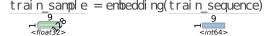

In [10]:
with tsensor.explain(fontname='Hack', dimfontname='Hack'):
    train_sample = embedding(train_sequence)

In [11]:
train_sample[0]

<tf.Tensor: shape=(9, 128), dtype=float32, numpy=
array([[ 0.02767906,  0.01698864, -0.00218344, ..., -0.03493733,
        -0.01924882, -0.03419378],
       [-0.00325478, -0.03192722, -0.00399429, ...,  0.03916946,
         0.02054247, -0.02621552],
       [-0.0044018 ,  0.04491374, -0.02927812, ...,  0.03737659,
        -0.02293534,  0.00672603],
       ...,
       [ 0.02767906,  0.01698864, -0.00218344, ..., -0.03493733,
        -0.01924882, -0.03419378],
       [ 0.01461145,  0.0399001 ,  0.04348297, ...,  0.04516179,
         0.00615822, -0.04319349],
       [-0.04976826,  0.04745663, -0.04084361, ..., -0.01010933,
         0.02055088, -0.00271774]], dtype=float32)>

## Averaging across tokens

In [12]:
GlobalAveragePooling1D()(train_sample)

<tf.Tensor: shape=(1, 128), dtype=float32, numpy=
array([[-0.0045085 ,  0.01850777, -0.00116567, -0.00025297, -0.01096052,
         0.00754521, -0.00603513, -0.01961341, -0.00321821,  0.01472974,
        -0.03130713,  0.00657566, -0.02509706,  0.00088031, -0.014433  ,
        -0.01509572,  0.00568138, -0.00608799, -0.00873973,  0.00071628,
        -0.00946529,  0.00993714, -0.00848676,  0.00227423, -0.01171647,
        -0.01624311,  0.00211956,  0.01303707, -0.0134521 ,  0.01266934,
         0.01057345, -0.00193512, -0.00416173,  0.01149706, -0.00417657,
        -0.01629446,  0.00905003, -0.00722006,  0.01009567, -0.00050784,
         0.00204767, -0.00138627, -0.00635653,  0.00579351,  0.00473833,
        -0.00744293,  0.02201858,  0.01359229, -0.00384959, -0.00223492,
         0.01216441, -0.00517753, -0.02121595, -0.00268054, -0.01249983,
        -0.00068184,  0.002143  ,  0.00574284,  0.01475081, -0.0098934 ,
        -0.00248491,  0.00890559, -0.0014385 , -0.00443148, -0.00039536,
 

![](images/Emb6.png)

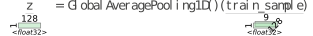

In [13]:
with tsensor.explain(fontname='Hack', dimfontname='Hack'):
    z = GlobalAveragePooling1D()(train_sample)

## Creating Word Embeddings for more than one sentence

In [14]:
# More than one sentence

test_corpus = [
    'The quick brown fox jumps over the lazy dog.',
    'The quick brown fox.',
    'The lazy dog.',
    'The dog.',
    'Dog and the fox.',
    'Hello, world!'
]
encoded_sentences = tokenizer.texts_to_sequences(test_corpus)
for sentence, encoded_sentence in zip(test_corpus, encoded_sentences):
    print(sentence, encoded_sentence)

The quick brown fox jumps over the lazy dog. [1, 2, 3, 4, 5, 6, 1, 7, 8]
The quick brown fox. [1, 2, 3, 4]
The lazy dog. [1, 7, 8]
The dog. [1, 8]
Dog and the fox. [8, 1, 4]
Hello, world! []


## Padding Sequences

In [15]:
# Length of each sentence in the corpus

[len(sentence) for sentence in encoded_sentences]

[9, 4, 3, 2, 3, 0]

In [16]:
# Length of the longest sentence

max([len(sentence) for sentence in encoded_sentences])

9

In [17]:
MAX_SEQUENCE_LENGTH = 9

In [18]:
# Padding sequences that are shorter than the longest sequence

X = pad_sequences(encoded_sentences, maxlen=MAX_SEQUENCE_LENGTH)
X

array([[1, 2, 3, 4, 5, 6, 1, 7, 8],
       [0, 0, 0, 0, 0, 1, 2, 3, 4],
       [0, 0, 0, 0, 0, 0, 1, 7, 8],
       [0, 0, 0, 0, 0, 0, 0, 1, 8],
       [0, 0, 0, 0, 0, 0, 8, 1, 4],
       [0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=int32)

## Embedding Layer

In [19]:
# Training data with more than 1 sentences

X.shape

(6, 9)

In [20]:
# Embeddings of the larger corpus

X_embedded = embedding(X)

In [21]:
X_embedded.shape

TensorShape([6, 9, 128])

In [22]:
X_embedded

<tf.Tensor: shape=(6, 9, 128), dtype=float32, numpy=
array([[[ 0.02767906,  0.01698864, -0.00218344, ..., -0.03493733,
         -0.01924882, -0.03419378],
        [-0.00325478, -0.03192722, -0.00399429, ...,  0.03916946,
          0.02054247, -0.02621552],
        [-0.0044018 ,  0.04491374, -0.02927812, ...,  0.03737659,
         -0.02293534,  0.00672603],
        ...,
        [ 0.02767906,  0.01698864, -0.00218344, ..., -0.03493733,
         -0.01924882, -0.03419378],
        [ 0.01461145,  0.0399001 ,  0.04348297, ...,  0.04516179,
          0.00615822, -0.04319349],
        [-0.04976826,  0.04745663, -0.04084361, ..., -0.01010933,
          0.02055088, -0.00271774]],

       [[ 0.00421996,  0.04786718,  0.01819999, ...,  0.0354032 ,
          0.03322962, -0.0301175 ],
        [ 0.00421996,  0.04786718,  0.01819999, ...,  0.0354032 ,
          0.03322962, -0.0301175 ],
        [ 0.00421996,  0.04786718,  0.01819999, ...,  0.0354032 ,
          0.03322962, -0.0301175 ],
        ...,
 

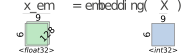

In [23]:
with tsensor.explain(fontname='Hack', dimfontname='Hack'):
    x_em = embedding(X)

In [24]:
X.shape

(6, 9)

In [25]:
x_em.shape

TensorShape([6, 9, 128])

## Averaging across tokens

![](images/Emb6.png)

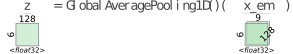

In [26]:
with tsensor.explain(fontname='Hack', dimfontname='Hack'):
    z = GlobalAveragePooling1D()(x_em)

In [27]:
z.shape

TensorShape([6, 128])

In [28]:
from datetime import datetime
import pytz

# Define the IST timezone
ist = pytz.timezone('Asia/Kolkata')

# Get the current time in UTC
utc_now = datetime.now(pytz.utc)

# Convert the current time to IST
ist_now = utc_now.astimezone(ist)

# Print the current time in IST
print("Current Time in IST:", ist_now.strftime('%Y-%m-%d %H:%M:%S'))

Current Time in IST: 2026-02-26 14:58:20


In [ ]:
# --- gcolab wrapper: list files in outputs/ ---
import os, datetime
_out_dir = 'outputs'
os.makedirs(_out_dir, exist_ok=True)
print(f"Files in {_out_dir}:")
_files = []
for _fn in os.listdir(_out_dir):
    _fp = os.path.join(_out_dir, _fn)
    if os.path.isfile(_fp):
        _st = os.stat(_fp)
        _files.append((datetime.datetime.fromtimestamp(_st.st_mtime).strftime('%Y-%m-%d %H:%M:%S'), _st.st_size, _fn))
_files.sort()
for _m, _s, _n in _files:
    if _s < 1024:
        _h = f"{_s} B"
    elif _s < 1024*1024:
        _h = f"{_s/1024:.2f} KB"
    else:
        _h = f"{_s/(1024*1024):.2f} MB"
    print(f"{_m}  {_h:>10}  {_n}")


In [ ]:
# --- gcolab wrapper: zip outputs/ -> outputs.zip ---
import os, shutil
os.makedirs('outputs', exist_ok=True)
shutil.make_archive('outputs', 'zip', 'outputs')
print('Created outputs.zip')
